In [279]:
import functions
import importlib
importlib.reload(functions)

from functions import *
import matplotlib.pyplot as plt



In [280]:
target_time = pd.Timestamp("2026-01-11 01:00:00")
rx_ecef = ECEF(55.738957, 12.500242, 20)

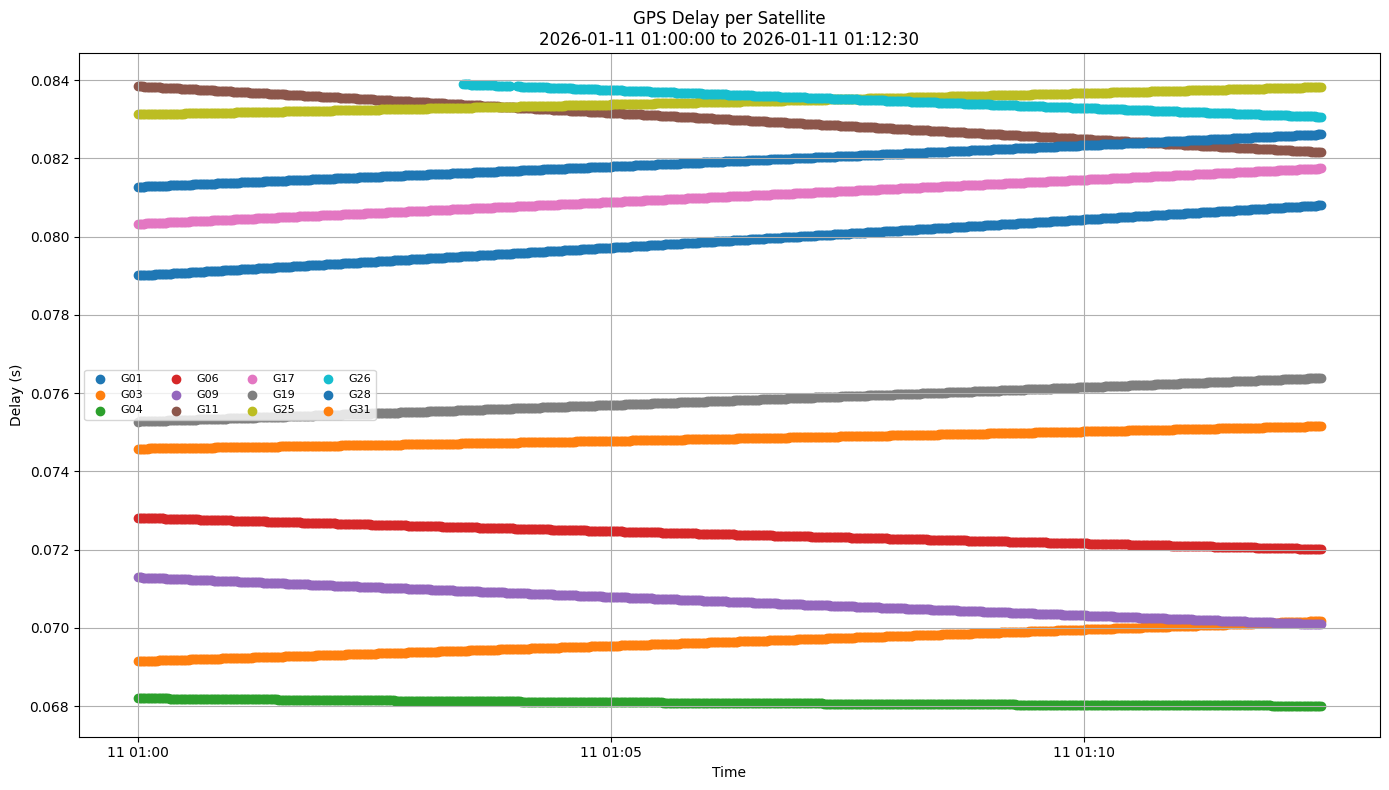

In [281]:
import pandas as pd
import matplotlib.pyplot as plt

C_MPS = 299_792_458.0

# load file
df = pd.read_csv("GPS_C1C_D1C.csv")
df["time"] = pd.to_datetime(df["time"])

# compute delay from pseudorange
df["delay_s"] = df["C1C_m"] / C_MPS

# satellites and time window
sv_order = [f"G{i:02d}" for i in range(1, 33)]
start_time = target_time
end_time = start_time + pd.Timedelta(minutes=12.5)
# filter to requested window and satellites
window_df = df[
    (df["sv"].isin(sv_order)) &
    (df["time"] >= start_time) &
    (df["time"] <= end_time)
].copy()

window_df = window_df.sort_values(["sv", "time"])

# plot delay for each satellite
plt.figure(figsize=(14, 8))

for sv in sv_order:
    sat_df = window_df[window_df["sv"] == sv]
    if not sat_df.empty:
        plt.scatter(sat_df["time"], sat_df["delay_s"], label=sv)

plt.xlabel("Time")
plt.ylabel("Delay (s)")
plt.title(f"GPS Delay per Satellite\n{start_time} to {end_time}")
plt.legend(ncol=4, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

In [282]:
import pandas as pd
import numpy as np

C_MPS = 299_792_458.0
N_BEST_SATS = 10

# load full extracted GPS observations
df = pd.read_csv("GPS_C1C_D1C.csv")
df["time"] = pd.to_datetime(df["time"])

# satellites and time window
# start with all GPS PRNs, then automatically select the best 6 from the window
sv_order_all = [f"G{i:02d}" for i in range(1, 33)]

start_time = target_time
end_time = start_time + pd.Timedelta(minutes=12.5)

# slice the window using all possible GPS satellites
window_df_all = df[
    (df["sv"].isin(sv_order_all)) &
    (df["time"] >= start_time) &
    (df["time"] <= end_time)
].copy()

window_df_all = window_df_all.sort_values(["time", "sv"]).reset_index(drop=True)
window_df_all["delay_s"] = window_df_all["C1C_m"] / C_MPS

print("rows before best-sat selection:", len(window_df_all))
print("time min/max:", window_df_all["time"].min(), window_df_all["time"].max())
print("sats present before best-sat selection:", window_df_all["sv"].unique())

# =============================================================================
# Pick the 6 best satellites in this time window
# =============================================================================

# one common epoch list for the whole selected window
all_epochs = window_df_all["time"].dropna().drop_duplicates().sort_values()
n_expected_epochs = len(all_epochs)

sat_quality_rows = []

for sv, sat_df in window_df_all.groupby("sv"):
    sat_df = sat_df.sort_values("time").copy()

    n_obs = len(sat_df)
    n_c1c = sat_df["C1C_m"].notna().sum()
    n_d1c = sat_df["D1C_hz"].notna().sum()

    # Fraction of epochs where this satellite exists
    availability = n_obs / n_expected_epochs if n_expected_epochs > 0 else 0.0

    # Count missing values
    n_nan_total = sat_df[["C1C_m", "D1C_hz"]].isna().sum().sum()

    # Pseudorange smoothness
    # Smaller jumps usually mean cleaner continuous tracking
    pr_diff = sat_df["C1C_m"].diff().abs()
    pr_jump_median = pr_diff.median()
    pr_jump_std = pr_diff.std()

    # Doppler smoothness
    dopp_diff = sat_df["D1C_hz"].diff().abs()
    dopp_jump_median = dopp_diff.median()
    dopp_jump_std = dopp_diff.std()

    sat_quality_rows.append({
        "sv": sv,
        "n_obs": n_obs,
        "n_c1c": n_c1c,
        "n_d1c": n_d1c,
        "availability": availability,
        "n_nan_total": n_nan_total,
        "pr_jump_median": pr_jump_median,
        "pr_jump_std": pr_jump_std,
        "dopp_jump_median": dopp_jump_median,
        "dopp_jump_std": dopp_jump_std,
    })

sat_quality = pd.DataFrame(sat_quality_rows)

# If no satellites were found, stop early
if sat_quality.empty:
    raise ValueError("No GPS satellites found in the selected time window.")

# Single-point or broken satellites can create NaNs in diff stats.
# Fill with infinity so they rank badly.
sat_quality["pr_jump_median"] = sat_quality["pr_jump_median"].fillna(np.inf)
sat_quality["pr_jump_std"] = sat_quality["pr_jump_std"].fillna(np.inf)
sat_quality["dopp_jump_median"] = sat_quality["dopp_jump_median"].fillna(np.inf)
sat_quality["dopp_jump_std"] = sat_quality["dopp_jump_std"].fillna(np.inf)

# Sort rule:
#   1. most complete satellite track
#   2. fewest missing values
#   3. smoothest pseudorange
#   4. smoothest Doppler
sat_quality = sat_quality.sort_values(
    by=[
        "availability",
        "n_obs",
        "n_nan_total",
        "pr_jump_median",
        "dopp_jump_median",
        "pr_jump_std",
        "dopp_jump_std",
    ],
    ascending=[
        False,
        False,
        True,
        True,
        True,
        True,
        True,
    ]
).reset_index(drop=True)

# selected satellite labels, e.g. ["G03", "G06", ...]
sv_order = sat_quality["sv"].head(N_BEST_SATS).tolist()

# integer PRNs for the rest of your code, e.g. [3, 6, ...]
sv_nums = [int(sv[1:]) for sv in sv_order]

# same thing under the name used elsewhere in your pipeline
wanted_sats = sv_order.copy()

print("\n===== SATELLITE QUALITY RANKING =====")
print(sat_quality.head(12))

print("\nSelected best satellites:")
print("sv_order:", sv_order)
print("sv_nums:", sv_nums)
print("wanted_sats:", wanted_sats)

# =============================================================================
# Continue using only the selected 6 satellites
# =============================================================================

# slice the window down to the selected best satellites
window_df = window_df_all[
    window_df_all["sv"].isin(sv_order)
].copy()

window_df = window_df.sort_values(["time", "sv"]).reset_index(drop=True)

print("\nrows after best-sat selection:", len(window_df))
print("time min/max:", window_df["time"].min(), window_df["time"].max())
print("sats present:", window_df["sv"].unique())

# one dataframe per satellite BEFORE interpolation
sat_frames = {
    sv: grp.copy().reset_index(drop=True)
    for sv, grp in window_df.groupby("sv")
}

# print number of raw data points per satellite
print("\nraw data points per selected satellite:")
for sv in sv_order:
    n_points_before = len(sat_frames[sv]) if sv in sat_frames else 0
    print(f"{sv}: {n_points_before}")

# make sure all selected sats are present
for sv in sv_order:
    if sv not in sat_frames:
        print(f"Missing satellite: {sv}")

# build sat_data dict from raw observations
sat_data = {
    sv: {
        "time": sat_frames[sv]["time"].tolist(),
        "pseudorange_m": sat_frames[sv]["C1C_m"].tolist(),
        "delay_s": sat_frames[sv]["delay_s"].tolist(),
        "doppler_hz": sat_frames[sv]["D1C_hz"].tolist(),
    }
    for sv in sv_order
    if sv in sat_frames
}

# align into matrices with one common time index
pivot_pr = (
    window_df
    .pivot(index="time", columns="sv", values="C1C_m")
    .reindex(columns=sv_order)
)

pivot_delay = (
    window_df
    .pivot(index="time", columns="sv", values="delay_s")
    .reindex(columns=sv_order)
)

pivot_dopp = (
    window_df
    .pivot(index="time", columns="sv", values="D1C_hz")
    .reindex(columns=sv_order)
)

# count original non-missing data points before interpolation
print("\noriginal non-NaN points:")
print("pseudorange:", pivot_pr.notna().sum().sum())
print("delay:", pivot_delay.notna().sum().sum())
print("doppler:", pivot_dopp.notna().sum().sum())

# interpolate missing values inside the window
pivot_pr = pivot_pr.interpolate(limit_direction="both")
pivot_delay = pivot_delay.interpolate(limit_direction="both")
pivot_dopp = pivot_dopp.interpolate(limit_direction="both")

# arrays for simulator: shape = (n_sats, n_times)
pseudorange_list = pivot_pr.to_numpy(dtype=float).T
delay_list = pivot_delay.to_numpy(dtype=float).T
doppler_list = pivot_dopp.to_numpy(dtype=float).T
time_list = pivot_delay.index.to_numpy()

print("\ninterpolated array shapes:")
print("pseudorange_list shape:", pseudorange_list.shape)
print("delay_list shape:", delay_list.shape)
print("doppler_list shape:", doppler_list.shape)
print("time_list shape:", time_list.shape)

print("\ntotal matrix points after interpolation:")
print("pseudorange_list:", pseudorange_list.size)
print("delay_list:", delay_list.size)
print("doppler_list:", doppler_list.size)

print("\nNaNs after interpolation:")
print("pseudorange:", np.isnan(pseudorange_list).sum())
print("delay:", np.isnan(delay_list).sum())
print("doppler:", np.isnan(doppler_list).sum())

# print RAW values before interpolation
print("\n===== RAW DATA PER SELECTED SATELLITE (before interpolation) =====")
for sv in sv_order:
    if sv in sat_frames:
        raw_times = sat_frames[sv]["time"].to_numpy()
        raw_pr = sat_frames[sv]["C1C_m"].to_numpy()
        raw_delay = sat_frames[sv]["delay_s"].to_numpy()
        raw_dopp = sat_frames[sv]["D1C_hz"].to_numpy()
        n_points_before = len(raw_times)
    else:
        raw_times = np.array([])
        raw_pr = np.array([])
        raw_delay = np.array([])
        raw_dopp = np.array([])
        n_points_before = 0

    print(f"\n{sv}")
    print(" data points before interpolation:", n_points_before)
    print(" first raw times:", raw_times[:3])
    print(" first raw pseudoranges:", raw_pr[:3])
    print(" first raw delays:", raw_delay[:3])
    print(" first raw dopplers:", raw_dopp[:3])

# optional: print INTERPOLATED values separately
print("\n===== INTERPOLATED DATA PER SELECTED SATELLITE =====")
for i, sv in enumerate(sv_order):
    print(f"\n{sv}")
    print(" first interpolated times:", time_list[:3])
    print(" first interpolated pseudoranges:", pseudorange_list[i, :3])
    print(" first interpolated delays:", delay_list[i, :3])
    print(" first interpolated dopplers:", doppler_list[i, :3])

rows before best-sat selection: 8806
time min/max: 2026-01-11 01:00:00 2026-01-11 01:12:30
sats present before best-sat selection: <StringArray>
['G01', 'G03', 'G04', 'G06', 'G09', 'G11', 'G17', 'G19', 'G25', 'G28', 'G31',
 'G26']
Length: 12, dtype: str

===== SATELLITE QUALITY RANKING =====
     sv  n_obs  n_c1c  n_d1c  availability  n_nan_total  pr_jump_median  \
0   G04    751    751    751      1.000000            0         76.0740   
1   G31    751    751    751      1.000000            0        230.0920   
2   G25    751    751    751      1.000000            0        280.4330   
3   G06    751    751    751      1.000000            0        320.1505   
4   G03    751    751    751      1.000000            0        409.7930   
5   G19    751    751    751      1.000000            0        445.3965   
6   G09    751    751    751      1.000000            0        480.2625   
7   G28    751    751    751      1.000000            0        536.5660   
8   G17    751    751    751    

In [283]:
"""import pandas as pd
import matplotlib.pyplot as plt

# load file
df = pd.read_csv("GPS_C1C_D1C.csv")
df["time"] = pd.to_datetime(df["time"])

# satellites and time window
sv_order = [f"G{i:02d}" for i in range(1, 33)]
start_time = pd.Timestamp("2026-01-11 02:00:00")
end_time = start_time + pd.Timedelta(minutes=60.5)

# filter to requested window and satellites
window_df = df[
    (df["sv"].isin(sv_order)) &
    (df["time"] >= start_time) &
    (df["time"] <= end_time)
].copy()

window_df = window_df.sort_values(["sv", "time"])

# plot doppler for each satellite
plt.figure(figsize=(14, 8))

for sv in sv_order:
    sat_df = window_df[window_df["sv"] == sv]
    if not sat_df.empty:
        plt.scatter(sat_df["time"], sat_df["D1C_hz"], label=sv)

plt.xlabel("Time")
plt.ylabel("Doppler (Hz)")
plt.title(f"GPS Doppler per Satellite\n{start_time} to {end_time}")
plt.legend(ncol=4, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()"""

'import pandas as pd\nimport matplotlib.pyplot as plt\n\n# load file\ndf = pd.read_csv("GPS_C1C_D1C.csv")\ndf["time"] = pd.to_datetime(df["time"])\n\n# satellites and time window\nsv_order = [f"G{i:02d}" for i in range(1, 33)]\nstart_time = pd.Timestamp("2026-01-11 02:00:00")\nend_time = start_time + pd.Timedelta(minutes=60.5)\n\n# filter to requested window and satellites\nwindow_df = df[\n    (df["sv"].isin(sv_order)) &\n    (df["time"] >= start_time) &\n    (df["time"] <= end_time)\n].copy()\n\nwindow_df = window_df.sort_values(["sv", "time"])\n\n# plot doppler for each satellite\nplt.figure(figsize=(14, 8))\n\nfor sv in sv_order:\n    sat_df = window_df[window_df["sv"] == sv]\n    if not sat_df.empty:\n        plt.scatter(sat_df["time"], sat_df["D1C_hz"], label=sv)\n\nplt.xlabel("Time")\nplt.ylabel("Doppler (Hz)")\nplt.title(f"GPS Doppler per Satellite\n{start_time} to {end_time}")\nplt.legend(ncol=4, fontsize=8)\nplt.grid(True)\nplt.tight_layout()\nplt.show()'

In [284]:
C = 299792458.0
GPS_UTC_LEAP_SECONDS = 18

def utc_datetime_to_gpsweek_and_sow(dt, leap_seconds=GPS_UTC_LEAP_SECONDS):
    """
    Convert a UTC-like datetime to GPS week and GPS seconds-of-week.

    GPS time = UTC time + leap seconds.
    For your 2026 RINEX/OBS data, leap_seconds = 18.
    """
    gps0 = pd.Timestamp("1980-01-06T00:00:00Z")

    dt = pd.Timestamp(dt)

    if dt.tzinfo is None:
        dt = dt.tz_localize("UTC")
    else:
        dt = dt.tz_convert("UTC")

    dt_gps = dt + pd.Timedelta(seconds=leap_seconds)

    sec = (dt_gps - gps0).total_seconds()
    gps_week = int(sec // 604800)
    sow = float(sec - gps_week * 604800)

    return gps_week, sow

In [285]:
# Convert to GPS SOW if your eph() expects numeric GPS SOW
_, target_sow = utc_datetime_to_gpsweek_and_sow(target_time)

print(target_sow)
Z_count_start = int(round(target_sow / 6.0)) + 1
print(Z_count_start)
sv_labels = [f"G{i:02d}" for i in sv_nums]

receiver_ecef = ECEF(buddinge[0], buddinge[1], buddinge[2])


res = {
    sv: modulo2_frames_runs(
        SV=sv,
        Z_count=Z_count_start,
        PRN=sv,
        target_time=target_sow
    )
    for sv in sv_nums
}

rho = {
    sv: np.sqrt(sum((ehpm_to_ECEFlocation_at_time(sv,target_sow) - receiver_ecef) ** 2))
    for sv in sv_nums
}

chips = {
    sv: np.frombuffer(res[sv].unpack(), dtype=np.uint8)
    for sv in sv_nums
}

chip_streams_01 = [chips[sv] for sv in sv_nums]
distances_m = np.array([rho[sv] for sv in sv_nums], dtype=float)
phase0 = np.array([2 * np.pi / (i + 1) for i in range(len(sv_nums))], dtype=float)

doppler_list = np.array(
    [sat_frames[f"G{sv:02d}"]["D1C_hz"].tolist() for sv in sv_nums],
    dtype=float
)

delay_list = np.array(
    [sat_frames[f"G{sv:02d}"]["delay_s"].tolist() for sv in sv_nums],
    dtype=float
)

amplitudes = np.full(len(sv_nums), 0.1, dtype=float)

print(len(delay_list))

3618.0
604
10


In [286]:
# satellites used in simulator
wanted_sats = [f"G{sv:02d}" for sv in sv_nums]

# selected time window
start_time = target_time
end_time = start_time + pd.Timedelta(minutes=12.5)

window_df = df[
    (df["sv"].isin(wanted_sats)) &
    (df["time"] >= start_time) &
    (df["time"] <= end_time)
].copy()

window_df = window_df.sort_values(["time", "sv"]).reset_index(drop=True)

print("window_df rows:", len(window_df))
print("window_df time min/max:", window_df["time"].min(), window_df["time"].max())
print("window_df sats:", window_df["sv"].unique())

# clean delays ONLY from the selected window
delay_df = build_delay_list_from_obs_df_simple(
    df=window_df,
    rx_ecef=rx_ecef,
    include_sat_clock=True,
)

print("delay_df rows:", len(delay_df))
print("delay_df time min/max:", delay_df["obs_time"].min(), delay_df["obs_time"].max())
print("delay_df sats:", delay_df["sv_str"].unique())

# delay matrix
pivot_clean_delay = (
    delay_df
    .pivot(index="obs_time", columns="sv_str", values="delay_seconds")
    .reindex(columns=wanted_sats)
)

pivot_clean_delay = pivot_clean_delay.interpolate(limit_direction="both")

delay_list = pivot_clean_delay.to_numpy(dtype=float).T
time_list = pivot_clean_delay.index.to_numpy()

# doppler matrix, aligned to delay time index
pivot_dopp = (
    window_df
    .pivot(index="time", columns="sv", values="D1C_hz")
    .reindex(columns=wanted_sats)
)

pivot_dopp = pivot_dopp.reindex(pivot_clean_delay.index)
pivot_dopp = pivot_dopp.interpolate(limit_direction="both")

doppler_list = pivot_dopp.to_numpy(dtype=float).T

print("delay_list shape:", delay_list.shape)
print("doppler_list shape:", doppler_list.shape)
print("time_list shape:", time_list.shape)

print("NaNs in delay_list:", np.isnan(delay_list).sum())
print("NaNs in doppler_list:", np.isnan(doppler_list).sum())

pivot_dopp = (
    window_df
    .pivot(index="time", columns="sv", values="D1C_hz")
    .reindex(columns=wanted_sats)
)

pivot_dopp = pivot_dopp.reindex(pivot_clean_delay.index)
pivot_dopp = pivot_dopp.interpolate(limit_direction="both")

doppler_list = pivot_dopp.to_numpy(dtype=float).T

print("doppler_list shape:", doppler_list.shape)
print("NaNs in doppler_list:", np.isnan(doppler_list).sum())

window_df rows: 7510
window_df time min/max: 2026-01-11 01:00:00 2026-01-11 01:12:30
window_df sats: <StringArray>
['G03', 'G04', 'G06', 'G09', 'G11', 'G17', 'G19', 'G25', 'G28', 'G31']
Length: 10, dtype: str
delay_df rows: 7510
delay_df time min/max: 2026-01-11 01:00:00 2026-01-11 01:12:30
delay_df sats: <StringArray>
['G03', 'G04', 'G06', 'G09', 'G11', 'G17', 'G19', 'G25', 'G28', 'G31']
Length: 10, dtype: str
delay_list shape: (10, 751)
doppler_list shape: (10, 751)
time_list shape: (751,)
NaNs in delay_list: 0
NaNs in doppler_list: 0
doppler_list shape: (10, 751)
NaNs in doppler_list: 0


In [287]:

delay_arrays = [
    delay_df[delay_df["sv_str"] == sat]
        .sort_values("obs_time")["delay_seconds"]
        .to_numpy()
    for sat in wanted_sats
]

In [288]:
print("target_time:", target_time)
print("target_sow:", target_sow)
print("Z_count_start:", Z_count_start)

receiver_ecef = ECEF(buddinge[0], buddinge[1], buddinge[2])
print("receiver_ecef:", receiver_ecef)

for sv in sv_nums:
    eph_idx = select_eph_idx(sv, target_sow)
    sat_xyz = ehpm_to_ECEFlocation_at_time(sv, target_sow, eph_idx)
    rho = np.linalg.norm(sat_xyz - receiver_ecef)

    print(
        f"G{sv:02d}",
        "eph_idx:", eph_idx,
        "Toe:", tables[SV_input_dict[sv]]['Toe'].iloc[eph_idx],
        "rho_km:", rho / 1000,
        "sat_norm_km:", np.linalg.norm(sat_xyz) / 1000,
    )

target_time: 2026-01-11 01:00:00
target_sow: 3618.0
Z_count_start: 604
receiver_ecef: (3513600.2213047445, 778961.9855037304, 5248151.334541669)
G04 eph_idx: 0 Toe: 7200.0 rho_km: 20405.626337544996 sat_norm_km: 26628.43706341498
G31 eph_idx: 0 Toe: 7200.0 rho_km: 22259.708203259088 sat_norm_km: 26285.840258187785
G25 eph_idx: 0 Toe: 7184.0 rho_km: 25008.697606744172 sat_norm_km: 26279.931735263788
G06 eph_idx: 0 Toe: 7184.0 rho_km: 21592.63304725156 sat_norm_km: 26626.311655928435
G03 eph_idx: 0 Toe: 7200.0 rho_km: 20867.72475214288 sat_norm_km: 26455.707703721146
G19 eph_idx: 1 Toe: 7184.0 rho_km: 22729.213631410905 sat_norm_km: 26283.87426315213
G09 eph_idx: 0 Toe: 7184.0 rho_km: 21544.29969661631 sat_norm_km: 26552.371889257953
G28 eph_idx: 0 Toe: 7200.0 rho_km: 24140.17386833957 sat_norm_km: 26558.61724513167
G17 eph_idx: 0 Toe: 7200.0 rho_km: 24032.15092998822 sat_norm_km: 26756.8096701188
G11 eph_idx: 0 Toe: 7200.0 rho_km: 24929.90354917154 sat_norm_km: 26620.48914005272


In [289]:

delay_arrays = [
    delay_df[delay_df["sv_str"] == sat]
        .sort_values("obs_time")["delay_seconds"]
        .to_numpy()
    for sat in wanted_sats
]
delay_matrix = np.vstack(delay_arrays)

In [290]:
#KEEEEEEP

epoch_times_s = np.arange(delay_matrix.shape[1], dtype=np.float64)
n_written = sample_chip_sequences_to_iq_file_variable_delay_doppler(
    chip_streams_01=chip_streams_01,
    delay_list=delay_list,
    doppler_hz_chunks=doppler_list,
    epoch_times_s=epoch_times_s,
    out_file="gps_signal2_iq_fc32.dat",
    fs=4.0e6,
    chip_rate=1.023e6,
    noise_std=0.00,
    max_chunks=50,   # only first 50 segments
    verbose=True,
)

delay_list shape: (10, 751)
doppler_hz_chunks shape: (10, 751)
epoch_times_s[0:5]: [0. 1. 2. 3. 4.]
signal duration (s): 750.0
signal samples: 3000000000
segments: 50
segment 1/50: t=[0.000000, 1.000000) s, samples=4000000
segment 2/50: t=[1.000000, 2.000000) s, samples=4000000
segment 3/50: t=[2.000000, 3.000000) s, samples=4000000
segment 4/50: t=[3.000000, 4.000000) s, samples=4000000
segment 5/50: t=[4.000000, 5.000000) s, samples=4000000
segment 6/50: t=[5.000000, 6.000000) s, samples=4000000
segment 7/50: t=[6.000000, 7.000000) s, samples=4000000
segment 8/50: t=[7.000000, 8.000000) s, samples=4000000
segment 9/50: t=[8.000000, 9.000000) s, samples=4000000
segment 10/50: t=[9.000000, 10.000000) s, samples=4000000
segment 11/50: t=[10.000000, 11.000000) s, samples=4000000
segment 12/50: t=[11.000000, 12.000000) s, samples=4000000
segment 13/50: t=[12.000000, 13.000000) s, samples=4000000
segment 14/50: t=[13.000000, 14.000000) s, samples=4000000
segment 15/50: t=[14.000000, 15.000